In [1]:
#######  V2 #############


import torch
import torch.nn as nn
import torch.nn.functional as F

from groupy.gconv.pytorch_gconv.splitgconv2d import P4ConvZ2, P4ConvP4
from groupy.gconv.pytorch_gconv import P4MConvZ2, P4MConvP4M
from groupy.gconv.pytorch_gconv.pooling import plane_group_spatial_max_pooling

class NNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(NNet, self).__init__()
        

        self.conv1 = P4MConvZ2(in_channels, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = P4MConvP4M(32, 32, kernel_size=3, stride=1, padding=1)

        self.conv3 = P4MConvP4M(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv4 = P4MConvP4M(64, 128, kernel_size=3, stride=1, padding=1)

        self.conv5 = P4MConvP4M(128, 64, kernel_size=3, padding=1)
        self.conv6 = P4MConvP4M(64, 32, kernel_size=3, padding=1)

#         self.conv3 = P4MConvP4M(48, 96, kernel_size=3, stride=1, padding=1)
#         self.conv4 = P4MConvP4M(96, 192, kernel_size=3, stride=1, padding=1)

#         self.conv5 = P4MConvP4M(192, 96, kernel_size=3, padding=1)
#         self.conv6 = P4MConvP4M(96, 48, kernel_size=3, padding=1)
        self.convt = nn.ConvTranspose2d(32*8, out_channels, kernel_size=2, stride=2, output_padding=0)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = plane_group_spatial_max_pooling(x, 2, 2)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        xs = x.size()
        x = x.view(xs[0], xs[1] * xs[2], xs[3], xs[4])
#         x = F.avg_pool2d(x, 2, 2)
        x = self.convt(x)

        return x

In [2]:
model = NNet(1, 1).cuda()
# model = ResNet18()

In [3]:
from torchsummary import summary
summary(model, (1, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         P4MConvZ2-1      [-1, 32, 8, 128, 128]             320
        P4MConvP4M-2      [-1, 32, 8, 128, 128]          73,760
        P4MConvP4M-3        [-1, 64, 8, 64, 64]         147,520
        P4MConvP4M-4       [-1, 128, 8, 64, 64]         589,952
        P4MConvP4M-5        [-1, 64, 8, 64, 64]         589,888
        P4MConvP4M-6        [-1, 32, 8, 64, 64]         147,488
   ConvTranspose2d-7          [-1, 1, 128, 128]           1,025
Total params: 1,549,953
Trainable params: 1,549,953
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.06
Forward/backward pass size (MB): 136.12
Params size (MB): 5.91
Estimated Total Size (MB): 142.10
----------------------------------------------------------------


In [4]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


class ERDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = os.listdir(root_dir)

    def __len__(self):
        return sum(len(os.listdir(os.path.join(self.root_dir, cls, 'images'))) for cls in self.classes)

    def __getitem__(self, idx):
        current_class_idx = 0
        while idx >= len(os.listdir(os.path.join(self.root_dir, self.classes[current_class_idx], 'images'))):
            idx -= len(os.listdir(os.path.join(self.root_dir, self.classes[current_class_idx], 'images')))
            current_class_idx += 1

        current_class = self.classes[current_class_idx]
        img_folder = os.path.join(self.root_dir, current_class, 'images')
        mask_folder = os.path.join(self.root_dir, current_class, 'masks')

        img_name = os.listdir(img_folder)[idx]
        img_path = os.path.join(img_folder, img_name)
        mask_name = os.path.splitext(img_name)[0] + '_mask.png'  # Assuming mask files have the same name as images with '_mask' appended
        mask_path = os.path.join(mask_folder, mask_name)

        image = Image.open(img_path)#.convert("RGB")
        mask = Image.open(mask_path)#.convert("L")  # Convert to grayscale mask

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

/localhome/asa420/anaconda3/envs/as3/lib/python3.7/site-packages/torchvision/io/image.py:11: UserWarning: Failed to load image Python extension: /local-scratch/localhome/asa420/anaconda3/envs/as3/lib/python3.7/site-packages/torchvision/image.so: undefined symbol: _ZNK3c1010TensorImpl36is_contiguous_nondefault_policy_implENS_12MemoryFormatE
  warn(f"Failed to load image Python extension: {e}")


In [5]:
import torch

class VectorAdam(torch.optim.Optimizer):
    def __init__(self, params, lr=0.1, betas=(0.9, 0.999), eps=1e-8, axis=-1):
        defaults = dict(lr=lr, betas=betas, eps=eps, axis=axis)
        super(VectorAdam, self).__init__(params, defaults)

    def __setstate__(self, state):
        super(VectorAdam, self).__setstate__(state)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group['lr']
            b1, b2 = group['betas']
            eps = group['eps']
            axis = group['axis']
            for p in group["params"]:
                state = self.state[p]
                # Lazy initialization
                if len(state) == 0:
                    state["step"] = 0
                    state["g1"] = torch.zeros_like(p.data)
                    state["g2"] = torch.zeros_like(p.data)

                g1 = state["g1"]
                g2 = state["g2"]
                state["step"] += 1
                grad = p.grad.data

                g1.mul_(b1).add_(grad, alpha=1-b1)
                if axis is not None:
                    dim = grad.shape[axis]
                    grad_norm = torch.norm(grad, dim=axis).unsqueeze(axis).repeat_interleave(dim, dim=axis)
                    grad_sq = grad_norm * grad_norm
                    g2.mul_(b2).add_(grad_sq, alpha=1-b2)
                else:
                    g2.mul_(b2).add_(grad.square(), alpha=1-b2)

                m1 = g1 / (1-(b1**state["step"]))
                m2 = g2 / (1-(b2**state["step"]))
                gr = m1 / (eps + m2.sqrt())
                p.data.sub_(gr, alpha=lr)

In [ ]:
# [6, 99, 88, 67, 108, 24, 76, 85, 61, 102, 69, 15, 34, 37, 110, 54, 39, 62, 82, 109, 78]
# {0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 38, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 55, 56, 57, 58, 59, 60, 63, 64, 65, 66, 68, 70, 71, 72, 73, 74, 75, 77, 79, 80, 81, 83, 84, 86, 87, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 100, 101, 103, 104, 105, 106, 107, 111, 112, 113, 114, 115, 116}

# [113, 59, 39, 54, 109, 99, 21, 8, 27, 98, 40, 92, 83, 43, 80, 5, 4, 60, 110, 45, 35]
# {0, 1, 2, 3, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 36, 37, 38, 41, 42, 44, 46, 47, 48, 49, 50, 51, 52, 53, 55, 56, 57, 58, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 81, 82, 84, 85, 86, 87, 88, 89, 90, 91, 93, 94, 95, 96, 97, 100, 101, 102, 103, 104, 105, 106, 107, 108, 111, 112, 114, 115, 116}

# [6, 35, 76, 90, 110, 96, 19, 53, 73, 88, 54, 70, 106, 38, 93, 48, 62, 66, 15, 39, 10]
# {0, 1, 2, 3, 4, 5, 7, 8, 9, 11, 12, 13, 14, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 36, 37, 40, 41, 42, 43, 44, 45, 46, 47, 49, 50, 51, 52, 55, 56, 57, 58, 59, 60, 61, 63, 64, 65, 67, 68, 69, 71, 72, 74, 75, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 89, 91, 92, 94, 95, 97, 98, 99, 100, 101, 102, 103, 104, 105, 107, 108, 109, 111, 112, 113, 114, 115, 116}

# [75, 12, 99, 105, 77, 100, 15, 32, 113, 57, 88, 85, 13, 98, 22, 80, 21, 17, 79, 40, 5]
# {0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 14, 16, 18, 19, 20, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 76, 78, 81, 82, 83, 84, 86, 87, 89, 90, 91, 92, 93, 94, 95, 96, 97, 101, 102, 103, 104, 106, 107, 108, 109, 110, 111, 112, 114, 115, 116}

# [6, 101, 37, 110, 67, 106, 58, 59, 87, 89, 113, 79, 17, 75, 68, 60, 4, 14, 26, 112, 80]
# {0, 1, 2, 3, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 61, 62, 63, 64, 65, 66, 69, 70, 71, 72, 73, 74, 76, 77, 78, 81, 82, 83, 84, 85, 86, 88, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 102, 103, 104, 105, 107, 108, 109, 111, 114, 115, 116}

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

import torch
from torch.utils.data import DataLoader, TensorDataset, sampler
from sklearn.model_selection import StratifiedKFold

# from model import NerdyNet
# from dataloader import ERDataset

import numpy as np

np.random.seed(34)
torch.manual_seed(34)

in_channels = 1
out_channels = 1  # Assuming binary segmentation
model = NNet(in_channels, out_channels)

# Define your loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

lr = 8e-4
betas = (0.9, 0.999)
eps = 1e-8

# optimizer = VectorAdam(
#     [{'params': X, 'axis': -1}, 
#      {'params': Y, 'axis':  1}], 
#      lr=lr, betas=betas, eps=eps)
optimizer = VectorAdam(
    [{'params': model.parameters(), 'axis': -1}],
     lr=lr, betas=betas, eps=eps)


# Define your transformation
transform = transforms.Compose([
    transforms.ToTensor()
])

# Define your dataset

root_dir = '/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/'

dataset = ERDataset(root_dir, transform=transform)

test_indices = [6, 101, 37, 110, 67, 106, 58, 59, 87, 89, 113, 79, 17, 75, 68, 60, 4, 14, 26, 112, 80]
train_indices = [0, 1, 2, 3, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 61, 62, 63, 64, 65, 66, 69, 70, 71, 72, 73, 74, 76, 77, 78, 81, 82, 83, 84, 85, 86, 88, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 102, 103, 104, 105, 107, 108, 109, 111, 114, 115, 116]


# Assuming an 80-20 train-test split
# train_size = int(0.85 * len(dataset))
# test_size = len(dataset) - train_size
# train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

batch_size = 32
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, sampler=sampler.SubsetRandomSampler(train_indices))
test_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, sampler=sampler.SubsetRandomSampler(test_indices))

# Training loop
num_epochs = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    for inputs, masks in train_loader:
        inputs, masks = inputs.to(device), masks.to(device)

        # Forward pass
        outputs = model(inputs)
#         outputs = (torch.sigmoid(outputs) > 0.5).float()
        loss = criterion(outputs, masks)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Print the training loss for each epoch
    print(f"Epoch [{epoch + 1}/{num_epochs}], Training Loss: {loss.item()}")

# Testing loop
model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, masks in test_loader:
        inputs, masks = inputs.to(device), masks.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, masks)
        test_loss += loss.item()

# Calculate and print the average test loss
average_test_loss = test_loss / len(test_loader)
print(f"Average Test Loss: {average_test_loss}")

# Save the trained model
torch.save(model.state_dict(), 'NNet_groupy_p4m_crossval_5.pth')


Epoch [1/100], Training Loss: 1.4423611164093018
Epoch [2/100], Training Loss: 0.5647639036178589
Epoch [3/100], Training Loss: 0.47247380018234253
Epoch [4/100], Training Loss: 0.4440472722053528
Epoch [5/100], Training Loss: 0.4042709469795227
Epoch [6/100], Training Loss: 0.38136231899261475
Epoch [7/100], Training Loss: 0.36264568567276
Epoch [8/100], Training Loss: 0.30639535188674927
Epoch [9/100], Training Loss: 0.28195369243621826
Epoch [10/100], Training Loss: 0.24675637483596802
Epoch [11/100], Training Loss: 0.24426016211509705
Epoch [12/100], Training Loss: 0.184696227312088
Epoch [13/100], Training Loss: 0.18932759761810303
Epoch [14/100], Training Loss: 0.19041717052459717
Epoch [15/100], Training Loss: 0.16309276223182678
Epoch [16/100], Training Loss: 0.16797348856925964
Epoch [17/100], Training Loss: 0.153885155916214
Epoch [18/100], Training Loss: 0.15754370391368866
Epoch [19/100], Training Loss: 0.14451603591442108
Epoch [20/100], Training Loss: 0.12927189469337463


In [7]:
from sklearn.metrics import f1_score

def compute_iou_metrics(pred_data, gt_data, process_pred_fn=None):
    metrics = []

    for pred, gt in zip(pred_data, gt_data):
    #     # if process_pred_fn:
    #     #     pred = process_pred_fn(pred)
    #     # metrics.append(SMet.intersection_over_union(pred, gt))
        if pred.max() == 255:
            pred = pred / 255
        if gt.max() == 255:
            gt = gt / 255
        metrics.append(torchmetrics.classification.BinaryJaccardIndex()(torch.tensor(pred), torch.tensor(gt)))

    return np.mean(metrics)


def compute_f1_score(pred_data, gt_data):
    metrics = []

    for pred_mask, true_mask in zip(pred_data, gt_data):
        # pred = pred.flatten()/255
        # gt = gt.flatten()/255
        # metrics.append(f1_score(gt, pred))
        if pred_mask.max() == 255:
            pred_mask = pred_mask / 255
        if true_mask.max() == 255:
            true_mask = true_mask / 255
        # metrics.append(SMet.f1_score(pred, gt))
        metrics.append(torchmetrics.classification.BinaryF1Score()(torch.tensor(pred_mask), torch.tensor(true_mask)))

    return np.mean(metrics)


def compute_dice_coefficient(pred_data, gt_data, process_pred_fn=None):
    metrics = []

    for pred_mask, true_mask in zip(pred_data, gt_data):
        # if process_pred_fn:
        #     pred = process_pred_fn(pred)

        if pred_mask.max() == 255.:
            pred_mask = pred_mask / 255.
        if true_mask.max() == 255.:
            true_mask = true_mask / 255.
        # metrics.append(SMet.dice_coefficient(pred, gt))
        metrics.append(torchmetrics.classification.Dice()(torch.tensor(pred_mask.astype('int')), torch.tensor(true_mask.astype('int'))))

    return np.mean(metrics)

In [ ]:
# [6, 99, 88, 67, 108, 24, 76, 85, 61, 102, 69, 15, 34, 37, 110, 54, 39, 62, 82, 109, 78]

# [113, 59, 39, 54, 109, 99, 21, 8, 27, 98, 40, 92, 83, 43, 80, 5, 4, 60, 110, 45, 35]

# [6, 35, 76, 90, 110, 96, 19, 53, 73, 88, 54, 70, 106, 38, 93, 48, 62, 66, 15, 39, 10]

# [75, 12, 99, 105, 77, 100, 15, 32, 113, 57, 88, 85, 13, 98, 22, 80, 21, 17, 79, 40, 5]

# [6, 101, 37, 110, 67, 106, 58, 59, 87, 89, 113, 79, 17, 75, 68, 60, 4, 14, 26, 112, 80]

In [8]:
# import shutil
# for i in range(1, 27):
#     os.rename(f'/localhome/asa420/MIAL/data/confocal-data/combined_masks/atl{i}_er_mean_mask.png', f'/localhome/asa420/MIAL/data/confocal-data/combined_masks/{i}_er_mean_mask.png')
# for i in range(1, 32):
#     os.rename(f'/localhome/asa420/MIAL/data/confocal-data/combined_masks/climp{i}_er_mean_mask.png', f'/localhome/asa420/MIAL/data/confocal-data/combined_masks/{i+26}_er_mean_mask.png')
# for i in range(1, 32):
#     os.rename(f'/localhome/asa420/MIAL/data/confocal-data/combined_masks/control{i}_er_mean_mask.png', f'/localhome/asa420/MIAL/data/confocal-data/combined_masks/{i+57}_er_mean_mask.png')
# for i in range(1, 30):
#     os.rename(f'/localhome/asa420/MIAL/data/confocal-data/combined_masks/rtn{i}_er_mean_mask.png', f'/localhome/asa420/MIAL/data/confocal-data/combined_masks/{i+88}_er_mean_mask.png')

In [31]:
in_channels = 1
out_channels = 1  # Assuming binary segmentation
model = NNet(in_channels, out_channels)

model.load_state_dict(torch.load('NNet_groupy_p4m_crossval_1.pth'))

<All keys matched successfully>

In [117]:
import imageio
from skimage import restoration
from skimage.filters import threshold_otsu, threshold_mean
import torchmetrics
import copy
import numpy as np

# split1 = [6, 99, 88, 67, 108, 24, 76, 85, 61, 102, 69, 15, 34, 37, 110, 54, 39, 62, 82, 109, 78]

# sorted_split1 = [6, 15, 24, 34, 37, 39, 54, 61, 62, 67, 69, 76, 78, 82, 85, 88, 99, 102, 108, 109, 110]

split1 = [61, 62, 67, 69, 76, 78, 82, 85, 88]


bop = []
op = []
p2 = []

for num in split1:
    imgpath = f'/localhome/asa420/MIAL/data/confocal-data/combined_data/{num}_er_mean.png'
    maskpath = f'/localhome/asa420/MIAL/data/confocal-data/combined_masks/{num}_er_mean_mask.png'

    mask = imageio.imread(maskpath)
    
    image = Image.open(imgpath)
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    image = transform(image)
    image = image.unsqueeze(0)  # Add batch dimension

    # Forward pass through the model
    model.eval()
    with torch.no_grad():
        output = model(image)

    # Convert the output to probabilities by applying the sigmoid activation
    output_probs = torch.sigmoid(output)

    # Convert tensors to numpy arrays for visualization
    image_np = image.squeeze().numpy()
    output_probs_np = output_probs.cpu().squeeze().numpy()

    norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())

    rb = restoration.rolling_ball(norm)
    subt = norm - rb

    thr = threshold_mean(subt) # Confocal

    subt2 = copy.deepcopy(subt)

    subt2[subt < thr] = 0.
    subt2[subt >= thr] = 255.
#     op.append(subt2)
    
    if subt2.max() == 255:
        subt2 = subt2 / 255
    if mask.max() == 255:
        mask = mask / 255
    bop.append(torchmetrics.classification.BinaryJaccardIndex()(torch.tensor(subt2), torch.tensor(mask)))
    
    if subt2.max() == 255:
        subt2 = subt2 / 255
    if mask.max() == 255:
        mask = mask / 255
        # metrics.append(SMet.f1_score(pred, gt))
    op.append(torchmetrics.classification.BinaryF1Score()(torch.tensor(subt2), torch.tensor(mask)))
    
    if subt2.max() == 255.:
        subt2 = subt2 / 255.
    if mask.max() == 255.:
        mask = mask / 255.
        # metrics.append(SMet.dice_coefficient(pred, gt))
    p2.append(torchmetrics.classification.Dice()(torch.tensor(subt2.astype('int')), torch.tensor(mask.astype('int'))))


print(np.mean(bop))
print(np.std(bop))
print(np.mean(op))
print(np.std(op))
print(np.mean(p2))
print(np.std(p2))

0.9112321
0.013982228
0.95349777
0.007762398
0.9777086
0.0062782723


In [53]:
# Confocal data results on competing methods

def get_results(group):
    split_prefix = '/localhome/asa420/MIAL/data/confocal-data/split1'

    ernop = []
    erv2op = []
    analyzerop = []
    nerdyop = []

    for num in range(1, 32):
        try:
            mask = imageio.imread(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/{group}/masks/{group}{num}_er_mean_mask.png')
            ernet = imageio.imread(f'{split_prefix}/{group}{num}_er_mean_out.png')
            erv2 = imageio.imread(f'{split_prefix}/{group}{num}_er_mean_out_bin.png')
            nerdy = imageio.imread(f'{split_prefix}/{group}{num}_er_mean_proc_enhance.png')
            analyzer = imageio.imread(f'{split_prefix}/ER_{group}{num}_bin_res.png')
            
            if mask.max() == 255:
                mask = mask / 255
            if ernet.max() == 255:
                ernet = ernet / 255
            if erv2.max() == 255:
                erv2 = erv2 / 255
            if nerdy.max() == 255:
                nerdy = nerdy / 255
            if analyzer.max() == 255:
                analyzer = analyzer / 255
#             ernop.append(torchmetrics.classification.Dice()(torch.tensor(ernet), torch.tensor(mask)))
#             erv2op.append(torchmetrics.classification.Dice()(torch.tensor(erv2), torch.tensor(mask)))
#             analyzerop.append(torchmetrics.classification.Dice()(torch.tensor(analyzer), torch.tensor(mask)))
#             nerdyop.append(torchmetrics.classification.Dice()(torch.tensor(nerdy), torch.tensor(mask)))
            
            ernop.append(torchmetrics.classification.Dice()(torch.tensor(ernet.astype('int')), torch.tensor(mask.astype('int'))))
            erv2op.append(torchmetrics.classification.Dice()(torch.tensor(erv2.astype('int')), torch.tensor(mask.astype('int'))))
            analyzerop.append(torchmetrics.classification.Dice()(torch.tensor(analyzer.astype('int')), torch.tensor(mask.astype('int'))))
            nerdyop.append(torchmetrics.classification.Dice()(torch.tensor(nerdy.astype('int')), torch.tensor(mask.astype('int'))))
        except:
            pass
    return ernop, erv2op, analyzerop, nerdyop

ernop, erv2op, analyzerop, nerdyop = get_results('rtn')
print(np.mean(ernop))
print(np.mean(erv2op))
print(np.mean(analyzerop))
print(np.mean(nerdyop))

11
14
20
21
22
0.89194334
0.8316528
0.779541
0.9116577


In [131]:
# Confocal data results on competing methods

def get_results(group):
    split_prefix = '/localhome/asa420/MIAL/data/confocal-data/split1'

    ernop = []
    erv2op = []
    analyzerop = []
    nerdyop = []

    for num in range(1, 32):
        try:
            mask = imageio.imread(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/{group}/masks/{group}{num}_er_mean_mask.png')
            ernet = imageio.imread(f'{split_prefix}/{group}{num}_er_mean_out.png')
            erv2 = imageio.imread(f'{split_prefix}/{group}{num}_er_mean_out_bin.png')
            nerdy = imageio.imread(f'{split_prefix}/{group}{num}_er_mean_proc_enhance.png')
            analyzer = imageio.imread(f'{split_prefix}/ER_{group}{num}_bin_res.png')
            
            if mask.max() == 255:
                mask = mask / 255
            if ernet.max() == 255:
                ernet = ernet / 255
            if erv2.max() == 255:
                erv2 = erv2 / 255
            if nerdy.max() == 255:
                nerdy = nerdy / 255
            if analyzer.max() == 255:
                analyzer = analyzer / 255
#             ernop.append(torchmetrics.classification.Dice()(torch.tensor(ernet), torch.tensor(mask)))
#             erv2op.append(torchmetrics.classification.Dice()(torch.tensor(erv2), torch.tensor(mask)))
#             analyzerop.append(torchmetrics.classification.Dice()(torch.tensor(analyzer), torch.tensor(mask)))
#             nerdyop.append(torchmetrics.classification.Dice()(torch.tensor(nerdy), torch.tensor(mask)))
            
            ernop.append(torchmetrics.classification.BinaryF1Score()(torch.tensor(ernet), torch.tensor(mask)))
            erv2op.append(torchmetrics.classification.BinaryF1Score()(torch.tensor(erv2), torch.tensor(mask)))
            analyzerop.append(torchmetrics.classification.BinaryF1Score()(torch.tensor(analyzer), torch.tensor(mask)))
            nerdyop.append(torchmetrics.classification.BinaryF1Score()(torch.tensor(nerdy), torch.tensor(mask)))
            
#             ernop.append(torchmetrics.classification.BinaryJaccardIndex()(torch.tensor(ernet), torch.tensor(mask)))
#             erv2op.append(torchmetrics.classification.BinaryJaccardIndex()(torch.tensor(erv2), torch.tensor(mask)))
#             analyzerop.append(torchmetrics.classification.BinaryJaccardIndex()(torch.tensor(analyzer), torch.tensor(mask)))
#             nerdyop.append(torchmetrics.classification.BinaryJaccardIndex()(torch.tensor(nerdy), torch.tensor(mask)))
        
#             ernop.append(torchmetrics.classification.Dice()(torch.tensor(ernet.astype('int')), torch.tensor(mask.astype('int'))))
#             erv2op.append(torchmetrics.classification.Dice()(torch.tensor(erv2.astype('int')), torch.tensor(mask.astype('int'))))
#             analyzerop.append(torchmetrics.classification.Dice()(torch.tensor(analyzer.astype('int')), torch.tensor(mask.astype('int'))))
#             nerdyop.append(torchmetrics.classification.Dice()(torch.tensor(nerdy.astype('int')), torch.tensor(mask.astype('int'))))
        except:
            pass
    return ernop, erv2op, analyzerop, nerdyop

ernop, erv2op, analyzerop, nerdyop = get_results('rtn')
print(np.mean(ernop))
print(np.std(ernop))
print(np.mean(erv2op))
print(np.std(erv2op))
print(np.mean(analyzerop))
print(np.std(analyzerop))
print(np.mean(nerdyop))
print(np.std(nerdyop))

0.796355
0.012352394
0.6855987
0.014077214
0.65591943
0.015599731
0.80797195
0.012671764


In [61]:
def nerdy_plus_op(imgpath):
    image = Image.open(imgpath)
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    image = transform(image)
    image = image.unsqueeze(0)  # Add batch dimension

    # Forward pass through the model
    model.eval()
    with torch.no_grad():
        output = model(image)

    # Convert the output to probabilities by applying the sigmoid activation
    output_probs = torch.sigmoid(output)

    # Convert tensors to numpy arrays for visualization
    image_np = image.squeeze().numpy()
    output_probs_np = output_probs.cpu().squeeze().numpy()

    norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())

    rb = restoration.rolling_ball(norm)
    subt = norm - rb

    thr = threshold_mean(subt) # Confocal

    subt2 = copy.deepcopy(subt)

    subt2[subt < thr] = 0.
    subt2[subt >= thr] = 255.
    
    return subt2

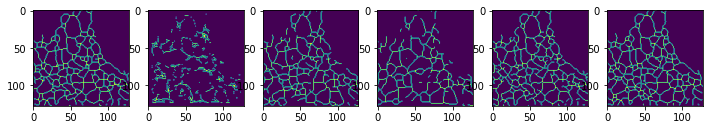

In [91]:
import matplotlib.pyplot as plt

group = 'atl'
for num in range(6, 7):
    mask = imageio.imread(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/{group}/masks/{group}{num}_er_mean_mask.png')
    img = nerdy_plus_op(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/{group}/images/{group}{num}_er_mean.png')
    ernet = imageio.imread(f'{split_prefix}/{group}{num}_er_mean_out.png')
    erv2 = imageio.imread(f'{split_prefix}/{group}{num}_er_mean_out_bin.png')
    nerdy = imageio.imread(f'{split_prefix}/{group}{num}_er_mean_proc_enhance.png')
    analyzer = imageio.imread(f'{split_prefix}/ER_{group}{num}_bin_res.png')

    img = img / 255
    p4mskel = skimage.morphology.skeletonize(img)
#     p4mskel = sknw.build_sknw(p4mskel, iso=False, multi=False)

    if mask.max() == 255:
        mask = mask / 255
        skel = skimage.morphology.skeletonize(mask)
#         skel = sknw.build_sknw(skel, iso=False, multi=False)
    if ernet.max() == 255:
        ernet = ernet / 255
        ernet = skimage.morphology.skeletonize(ernet)
#         ernet = sknw.build_sknw(ernet, iso=False, multi=False)
    if erv2.max() == 255:
        erv2 = erv2 / 255
        erv2 = skimage.morphology.skeletonize(erv2)
#         erv2 = sknw.build_sknw(erv2, iso=False, multi=False)
    if nerdy.max() == 255:
        nerdy = nerdy / 255
        nerdy = skimage.morphology.skeletonize(nerdy)
#         nerdy = sknw.build_sknw(nerdy, iso=False, multi=False)
    if analyzer.max() == 255:
        analyzer = analyzer / 255
        analyzer = skimage.morphology.skeletonize(analyzer)
#         analyzer = sknw.build_sknw(analyzer, iso=False, multi=False)

    plt.figure(figsize=(12, 12))
    plt.subplot(161)
    plt.imshow(skel)
    plt.subplot(162)
    plt.imshow(analyzer)
    plt.subplot(163)
    plt.imshow(ernet)
    plt.subplot(164)
    plt.imshow(erv2)
    plt.subplot(165)
    plt.imshow(nerdy)
    plt.subplot(166)
    plt.imshow(p4mskel)


In [113]:
import skimage
import networkx as nx
import sknw

def simple_analysis(G):
        no_nodes = G.number_of_nodes()
        no_edges = G.number_of_edges()
        assortativity = nx.degree_assortativity_coefficient(G)
        clustering = nx.average_clustering(G)
        compo = nx.number_connected_components(G)
        Gcc = sorted(nx.connected_components(G), key=len, reverse=True)
        G0 = G.subgraph(Gcc[0])
        size_G0_edges = G0.number_of_edges()
        size_G0_nodes = G0.number_of_nodes()
        ratio_nodes = size_G0_nodes / no_nodes
        ratio_edges = size_G0_edges / no_edges
        avg_clustering = nx.average_clustering(G)
        local_efficiency = nx.local_efficiency(G)
        global_efficiency = nx.global_efficiency(G)
        density = nx.density(G)
        return [
            no_nodes,
            no_edges,
            assortativity,
            clustering,
            compo,
            ratio_nodes,
            ratio_edges,
#             avg_clustering,
#             local_efficiency,
            global_efficiency,
            density
        ]

def get_results(group):
    split_prefix = '/localhome/asa420/MIAL/data/confocal-data/split1'

    gt = []
    ernop = []
    erv2op = []
    analyzerop = []
    nerdyop = []
    p4m = []

    for num in range(1, 32):
        try:
            mask = imageio.imread(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/{group}/masks/{group}{num}_er_mean_mask.png')
            img = nerdy_plus_op(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/{group}/images/{group}{num}_er_mean.png')
            ernet = imageio.imread(f'{split_prefix}/{group}{num}_er_mean_out.png')
            erv2 = imageio.imread(f'{split_prefix}/{group}{num}_er_mean_out_bin.png')
            nerdy = imageio.imread(f'{split_prefix}/{group}{num}_er_mean_proc_enhance.png')
            analyzer = imageio.imread(f'{split_prefix}/ER_{group}{num}_bin_res.png')
            
            img = img / 255
            p4mskel = skimage.morphology.skeletonize(img)
            p4mskel = sknw.build_sknw(p4mskel, iso=False, multi=False)
            
            if mask.max() == 255:
                mask = mask / 255
                skel = skimage.morphology.skeletonize(mask)
                skel = sknw.build_sknw(skel, iso=False, multi=False)
            if ernet.max() == 255:
                ernet = ernet / 255
                ernet = skimage.morphology.skeletonize(ernet)
                ernet = sknw.build_sknw(ernet, iso=False, multi=False)
            if erv2.max() == 255:
                erv2 = erv2 / 255
                erv2 = skimage.morphology.skeletonize(erv2)
                erv2 = sknw.build_sknw(erv2, iso=False, multi=False)
            if nerdy.max() == 255:
                nerdy = nerdy / 255
                nerdy = skimage.morphology.skeletonize(nerdy)
                nerdy = sknw.build_sknw(nerdy, iso=False, multi=False)
            if analyzer.max() == 255:
                analyzer = analyzer / 255
                analyzer = skimage.morphology.skeletonize(analyzer)
                analyzer = sknw.build_sknw(analyzer, iso=False, multi=False)
#             ernop.append(torchmetrics.classification.Dice()(torch.tensor(ernet), torch.tensor(mask)))
#             erv2op.append(torchmetrics.classification.Dice()(torch.tensor(erv2), torch.tensor(mask)))
#             analyzerop.append(torchmetrics.classification.Dice()(torch.tensor(analyzer), torch.tensor(mask)))
#             nerdyop.append(torchmetrics.classification.Dice()(torch.tensor(nerdy), torch.tensor(mask)))
            gt.append(simple_analysis(skel))
            ernop.append(simple_analysis(ernet))
            erv2op.append(simple_analysis(erv2))
            analyzerop.append(simple_analysis(analyzer))
            nerdyop.append(simple_analysis(nerdy))
            p4m.append(simple_analysis(p4mskel))
        except:
            pass
    return gt, ernop, erv2op, analyzerop, nerdyop, p4m

gt, ernop, erv2op, analyzerop, nerdyop, p4m = get_results('atl')

# def get_mean(nparr):
#     return [np.mean(lt) for lt in nparr]

# def get_error(gt, method):
#     err = []
#     for i in range(len(gt)):
#         val = abs(gt[i] - method[i]) / abs(gt[i])
#         err.append(val)
#     return err

gt_graph_metrics = np.array(gt).T
analyzer_graph_metrics = np.array(analyzerop).T
erv2_graph_metrics = np.array(erv2op).T
ernet_graph_metrics = np.array(ernop).T
nerdy_graph_metrics = np.array(nerdyop).T
p4m_graph_metrics = np.array(p4m).T


def get_rel_error(gt, method):
    op = []
    for gt_metric, method_metric in zip(gt, method):
        data = []    
        for v1, v2 in zip(gt_metric, method_metric):
            if v1 != 0:
                val = abs(v1 - v2) / abs(v1)
                data.append(val)
        op.append(data)
    return op

import numpy as np

def find_outliers(data, threshold=1.5):
    """
    Find outliers in a list of values using the IQR method.

    Parameters:
    - data: 1D array or list, the input data
    - threshold: float, a multiplier to determine the outlier range

    Returns:
    - outliers: 1D array, the values identified as outliers
    """
    # Convert data to a numpy array
    data = np.array(data)

    # Calculate the first and third quartiles
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)

    # Calculate the interquartile range (IQR)
    iqr = q3 - q1

    # Define the lower and upper bounds for outliers
    lower_bound = q1 - threshold * iqr
    upper_bound = q3 + threshold * iqr

    # Identify outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]

    return outliers




def get_variation(op):
    for num, metric in enumerate(op):
        if num == 2:
            outl = find_outliers(metric)
            for e in outl:
                metric.remove(e)
        mn = np.mean(metric)
        st = np.std(metric)
        print(f'{mn:.2f} +/- {st:.2f}')



# def bootstrapped_mean(data, num_samples=5):
#     """
#     Calculate the bootstrapped mean of a dataset.

#     Parameters:
#     - data: 1D array or list, the observed data
#     - num_samples: int, the number of bootstrap samples to generate

#     Returns:
#     - bootstrapped_means: 1D array, bootstrapped means
#     """
#     # Initialize an array to store bootstrapped means
#     bootstrapped_means = np.zeros(num_samples)

#     # Number of data points
#     n = len(data)

#     # Generate bootstrapped samples and calculate means
#     for i in range(num_samples):
#         bootstrap_sample = np.random.choice(data, size=n, replace=True)
#         bootstrapped_means[i] = np.mean(bootstrap_sample)

#     return bootstrapped_means

# analyzer_error = get_rel_error(gt_graph_metrics, analyzer_graph_metrics)
# for metric in analyzer_error:
#     bootstrap_means_result = bootstrapped_mean(metric, num_samples=5)

#     # Print the bootstrapped mean and its standard deviation
#     print("Bootstrapped Mean:", np.mean(bootstrap_means_result))
#     print("Bootstrapped Standard Deviation:", np.std(bootstrap_means_result))

    
analyzer_error = get_rel_error(gt_graph_metrics, analyzer_graph_metrics)
get_variation(analyzer_error)
print('----------------------')
ernet_error = get_rel_error(gt_graph_metrics, ernet_graph_metrics)
get_variation(ernet_error)
print('----------------------')
erv2_error = get_rel_error(gt_graph_metrics, erv2_graph_metrics)
get_variation(erv2_error)
print('----------------------')
nerdy_error = get_rel_error(gt_graph_metrics, nerdy_graph_metrics)
get_variation(nerdy_error)
print('----------------------')
p4m_error = get_rel_error(gt_graph_metrics, p4m_graph_metrics)
get_variation(p4m_error)
print('----------------------')


0.14 +/- 0.07
0.40 +/- 0.03
1.58 +/- 0.66
1.00 +/- 0.00
27.50 +/- 13.21
0.93 +/- 0.02
0.89 +/- 0.03
0.92 +/- 0.02
0.54 +/- 0.03
----------------------
0.11 +/- 0.05
0.22 +/- 0.02
1.43 +/- 0.51
0.37 +/- 0.22
2.58 +/- 3.12
0.08 +/- 0.07
0.04 +/- 0.05
0.12 +/- 0.13
0.08 +/- 0.04
----------------------
0.32 +/- 0.04
0.48 +/- 0.04
2.06 +/- 1.46
0.44 +/- 0.31
3.75 +/- 3.01
0.20 +/- 0.03
0.13 +/- 0.03
0.26 +/- 0.06
0.15 +/- 0.08
----------------------
0.14 +/- 0.08
0.02 +/- 0.02
2.00 +/- 1.15
0.41 +/- 0.30
2.33 +/- 2.60
0.05 +/- 0.04
0.03 +/- 0.02
0.19 +/- 0.10
0.23 +/- 0.08
----------------------
0.05 +/- 0.04
0.08 +/- 0.03
2.18 +/- 2.18
0.24 +/- 0.08
0.67 +/- 0.24
0.02 +/- 0.00
0.01 +/- 0.00
0.04 +/- 0.02
0.05 +/- 0.01
----------------------


In [ ]:
import skimage
import networkx as nx
import sknw

def simple_analysis(G):
        no_nodes = G.number_of_nodes()
        no_edges = G.number_of_edges()
        assortativity = nx.degree_assortativity_coefficient(G)
        clustering = nx.average_clustering(G)
        compo = nx.number_connected_components(G)
        Gcc = sorted(nx.connected_components(G), key=len, reverse=True)
        G0 = G.subgraph(Gcc[0])
        size_G0_edges = G0.number_of_edges()
        size_G0_nodes = G0.number_of_nodes()
        ratio_nodes = size_G0_nodes / no_nodes
        ratio_edges = size_G0_edges / no_edges
        avg_clustering = nx.average_clustering(G)
        local_efficiency = nx.local_efficiency(G)
        global_efficiency = nx.global_efficiency(G)
        density = nx.density(G)
        return [
            no_nodes,
            no_edges,
            assortativity,
            clustering,
            compo,
            ratio_nodes,
            ratio_edges,
#             avg_clustering,
#             local_efficiency,
            global_efficiency,
            density
        ]

def get_results(group):
    split_prefix = '/localhome/asa420/MIAL/data/confocal-data/split1'

    gt = []
    ernop = []
    erv2op = []
    analyzerop = []
    nerdyop = []
    p4m = []

    for num in range(1, 32):
        try:
            mask = imageio.imread(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/{group}/masks/{group}{num}_er_mean_mask.png')
            img = nerdy_plus_op(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/{group}/images/{group}{num}_er_mean.png')
            ernet = imageio.imread(f'{split_prefix}/{group}{num}_er_mean_out.png')
            erv2 = imageio.imread(f'{split_prefix}/{group}{num}_er_mean_out_bin.png')
            nerdy = imageio.imread(f'{split_prefix}/{group}{num}_er_mean_proc_enhance.png')
            analyzer = imageio.imread(f'{split_prefix}/ER_{group}{num}_bin_res.png')
            
            img = img / 255
            p4mskel = skimage.morphology.skeletonize(img)
            p4mskel = sknw.build_sknw(p4mskel, iso=False, multi=False)
            
            if mask.max() == 255:
                mask = mask / 255
                skel = skimage.morphology.skeletonize(mask)
                skel = sknw.build_sknw(skel, iso=False, multi=False)
            if ernet.max() == 255:
                ernet = ernet / 255
                ernet = skimage.morphology.skeletonize(ernet)
                ernet = sknw.build_sknw(ernet, iso=False, multi=False)
            if erv2.max() == 255:
                erv2 = erv2 / 255
                erv2 = skimage.morphology.skeletonize(erv2)
                erv2 = sknw.build_sknw(erv2, iso=False, multi=False)
            if nerdy.max() == 255:
                nerdy = nerdy / 255
                nerdy = skimage.morphology.skeletonize(nerdy)
                nerdy = sknw.build_sknw(nerdy, iso=False, multi=False)
            if analyzer.max() == 255:
                analyzer = analyzer / 255
                analyzer = skimage.morphology.skeletonize(analyzer)
                analyzer = sknw.build_sknw(analyzer, iso=False, multi=False)
#             ernop.append(torchmetrics.classification.Dice()(torch.tensor(ernet), torch.tensor(mask)))
#             erv2op.append(torchmetrics.classification.Dice()(torch.tensor(erv2), torch.tensor(mask)))
#             analyzerop.append(torchmetrics.classification.Dice()(torch.tensor(analyzer), torch.tensor(mask)))
#             nerdyop.append(torchmetrics.classification.Dice()(torch.tensor(nerdy), torch.tensor(mask)))
            gt.append(simple_analysis(skel))
            ernop.append(simple_analysis(ernet))
            erv2op.append(simple_analysis(erv2))
            analyzerop.append(simple_analysis(analyzer))
            nerdyop.append(simple_analysis(nerdy))
            p4m.append(simple_analysis(p4mskel))
        except:
            pass
    return gt, ernop, erv2op, analyzerop, nerdyop, p4m

gt, ernop, erv2op, analyzerop, nerdyop, p4m = get_results('atl')

# def get_mean(nparr):
#     return [np.mean(lt) for lt in nparr]

# def get_error(gt, method):
#     err = []
#     for i in range(len(gt)):
#         val = abs(gt[i] - method[i]) / abs(gt[i])
#         err.append(val)
#     return err

gt_graph_metrics = np.array(gt).T
analyzer_graph_metrics = np.array(analyzerop).T
erv2_graph_metrics = np.array(erv2op).T
ernet_graph_metrics = np.array(ernop).T
nerdy_graph_metrics = np.array(nerdyop).T
p4m_graph_metrics = np.array(p4m).T


def get_rel_error(gt, method):
    op = []
    for gt_metric, method_metric in zip(gt, method):
        data = []    
        for v1, v2 in zip(gt_metric, method_metric):
            if v1 != 0:
                val = abs(v1 - v2) / abs(v1)
                data.append(val)
        op.append(data)
    return op

import numpy as np

def find_outliers(data, threshold=1.5):
    """
    Find outliers in a list of values using the IQR method.

    Parameters:
    - data: 1D array or list, the input data
    - threshold: float, a multiplier to determine the outlier range

    Returns:
    - outliers: 1D array, the values identified as outliers
    """
    # Convert data to a numpy array
    data = np.array(data)

    # Calculate the first and third quartiles
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)

    # Calculate the interquartile range (IQR)
    iqr = q3 - q1

    # Define the lower and upper bounds for outliers
    lower_bound = q1 - threshold * iqr
    upper_bound = q3 + threshold * iqr

    # Identify outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]

    return outliers




def get_variation(op):
    for num, metric in enumerate(op):
        if num == 2:
            outl = find_outliers(metric)
            for e in outl:
                metric.remove(e)
        mn = np.mean(metric)
        st = np.std(metric)
        print(f'{mn:.2f} +/- {st:.2f}')



# def bootstrapped_mean(data, num_samples=5):
#     """
#     Calculate the bootstrapped mean of a dataset.

#     Parameters:
#     - data: 1D array or list, the observed data
#     - num_samples: int, the number of bootstrap samples to generate

#     Returns:
#     - bootstrapped_means: 1D array, bootstrapped means
#     """
#     # Initialize an array to store bootstrapped means
#     bootstrapped_means = np.zeros(num_samples)

#     # Number of data points
#     n = len(data)

#     # Generate bootstrapped samples and calculate means
#     for i in range(num_samples):
#         bootstrap_sample = np.random.choice(data, size=n, replace=True)
#         bootstrapped_means[i] = np.mean(bootstrap_sample)

#     return bootstrapped_means

# analyzer_error = get_rel_error(gt_graph_metrics, analyzer_graph_metrics)
# for metric in analyzer_error:
#     bootstrap_means_result = bootstrapped_mean(metric, num_samples=5)

#     # Print the bootstrapped mean and its standard deviation
#     print("Bootstrapped Mean:", np.mean(bootstrap_means_result))
#     print("Bootstrapped Standard Deviation:", np.std(bootstrap_means_result))

    
analyzer_error = get_rel_error(gt_graph_metrics, analyzer_graph_metrics)
get_variation(analyzer_error)
print('----------------------')
ernet_error = get_rel_error(gt_graph_metrics, ernet_graph_metrics)
get_variation(ernet_error)
print('----------------------')
erv2_error = get_rel_error(gt_graph_metrics, erv2_graph_metrics)
get_variation(erv2_error)
print('----------------------')
nerdy_error = get_rel_error(gt_graph_metrics, nerdy_graph_metrics)
get_variation(nerdy_error)
print('----------------------')
p4m_error = get_rel_error(gt_graph_metrics, p4m_graph_metrics)
get_variation(p4m_error)
print('----------------------')


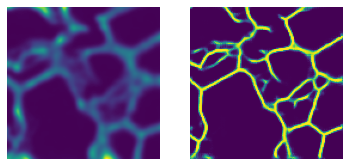

In [24]:
import matplotlib.pyplot as plt

plt.subplot(121)
plt.imshow(image[0][0])
plt.axis('off')

plt.subplot(122)
plt.imshow(norm)
plt.axis('off')

plt.show()

In [3]:
#######  V2 #############


import torch
import torch.nn as nn
import torch.nn.functional as F

from groupy.gconv.pytorch_gconv.splitgconv2d import P4ConvZ2, P4ConvP4
from groupy.gconv.pytorch_gconv import P4MConvZ2, P4MConvP4M
from groupy.gconv.pytorch_gconv.pooling import plane_group_spatial_max_pooling

class NNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(NNet, self).__init__()
        

        self.conv1 = P4MConvZ2(in_channels, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = P4MConvP4M(32, 32, kernel_size=3, stride=1, padding=1)

        self.conv3 = P4MConvP4M(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv4 = P4MConvP4M(64, 128, kernel_size=3, stride=1, padding=1)

        self.conv5 = P4MConvP4M(128, 64, kernel_size=3, padding=1)
        self.conv6 = P4MConvP4M(64, 32, kernel_size=3, padding=1)

#         self.conv3 = P4MConvP4M(48, 96, kernel_size=3, stride=1, padding=1)
#         self.conv4 = P4MConvP4M(96, 192, kernel_size=3, stride=1, padding=1)

#         self.conv5 = P4MConvP4M(192, 96, kernel_size=3, padding=1)
#         self.conv6 = P4MConvP4M(96, 48, kernel_size=3, padding=1)
        self.convt = nn.ConvTranspose2d(32*8, out_channels, kernel_size=2, stride=2, output_padding=0)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = plane_group_spatial_max_pooling(x, 2, 2)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        xs = x.size()
        x = x.view(xs[0], xs[1] * xs[2], xs[3], xs[4])
#         x = F.avg_pool2d(x, 2, 2)
        x = self.convt(x)

        return x

In [7]:
from skimage import restoration
from skimage.filters import threshold_otsu
import copy
import imageio
from PIL import Image


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

import numpy as np



# Define your transformation
transform = transforms.Compose([
    transforms.ToTensor()
])


model = NNet(1, 1)
model.load_state_dict(torch.load('/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/NNet_groupy_p4m_v2.pth'))

groups = ['climp', 'control', 'rtn']

for group in groups:
    for i in range(1, 17):
        try:
            imgpath = f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/{group}/er_mean_blur/{group}{i}_er_mean_blur.png'

            image = Image.open(imgpath)
            transform = transforms.Compose([
                transforms.ToTensor(),
            ])

            image = transform(image)
            image = image.unsqueeze(0)  # Add batch dimension

            # Forward pass through the model
            model.eval()
            with torch.no_grad():
                output = model(image)

            # Convert the output to probabilities by applying the sigmoid activation
            output_probs = torch.sigmoid(output)

            # Convert tensors to numpy arrays for visualization
            image_np = image.squeeze().numpy()
            output_probs_np = output_probs.cpu().squeeze().numpy()

            norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())

            rb = restoration.rolling_ball(norm)
            subt = norm - rb

            thr = threshold_otsu(subt)

            subt2 = copy.deepcopy(subt)

            subt2[subt < thr] = 0.
            subt2[subt >= thr] = 255.

#             imageio.imsave(f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/{group}/nerdynet_v2/sted_{group}{i}_er_mean_pred.png', subt2)
            imageio.imsave(f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/{group}/blur_p4m_v2/sted_{group}{i}_er_mean_pred.png', subt2)
        except:
            pass

Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
